# Daily Return Analysis

In [33]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
nav_his_clean_df = pd.read_csv('../data/processed/nav_history_cleaned.csv')
nav_his_clean_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [34]:
nav_his_clean_df['daily_return'] = (
    nav_his_clean_df.groupby('amfi_code')['nav'].pct_change()
)

In [35]:
nav_his_clean_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [36]:
nav_his_clean_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

###### The daily return distribution appears reasonable. The average daily return is positive (0.063%), with a standard deviation of approximately 1.03%, indicating moderate volatility. The minimum and maximum returns (-5.81% and +6.47%) fall within realistic market movement ranges, suggesting that the daily return calculations have been performed correctly.

## Histogram


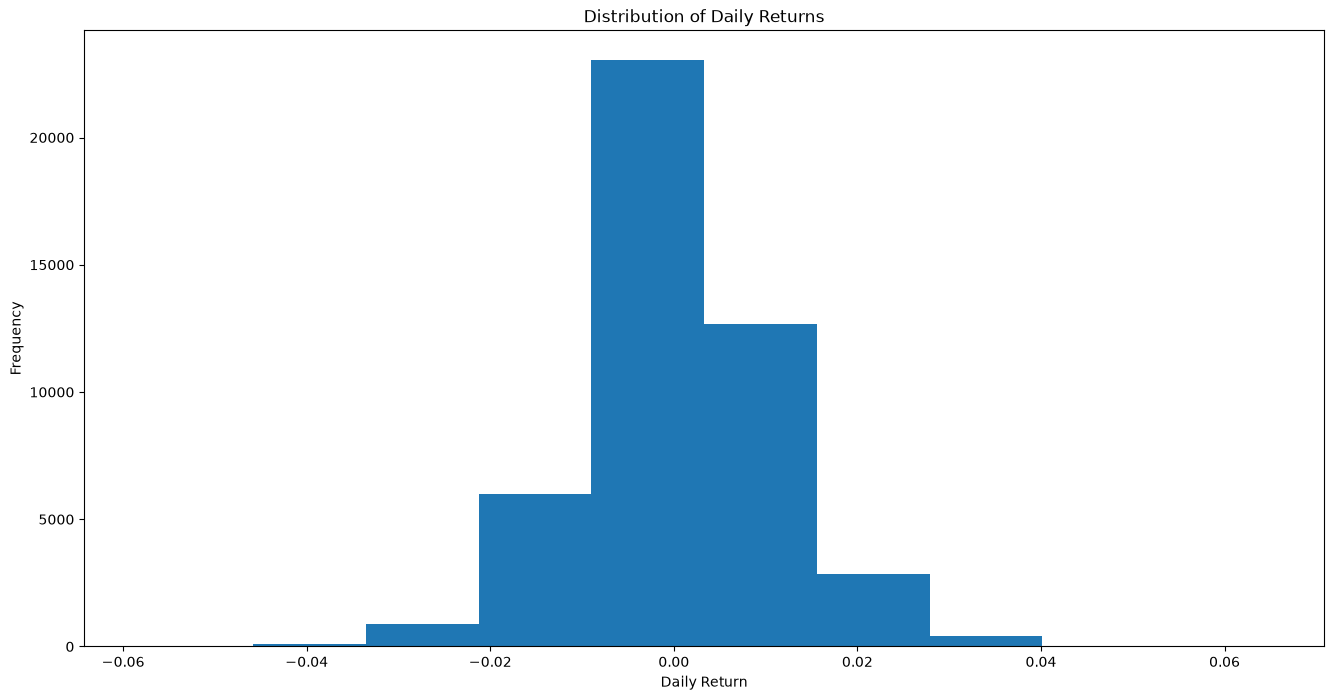

In [37]:
plt.figure(figsize=(16,8))


plt.hist(
    nav_his_clean_df['daily_return'].dropna(),
)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

## Box Plot

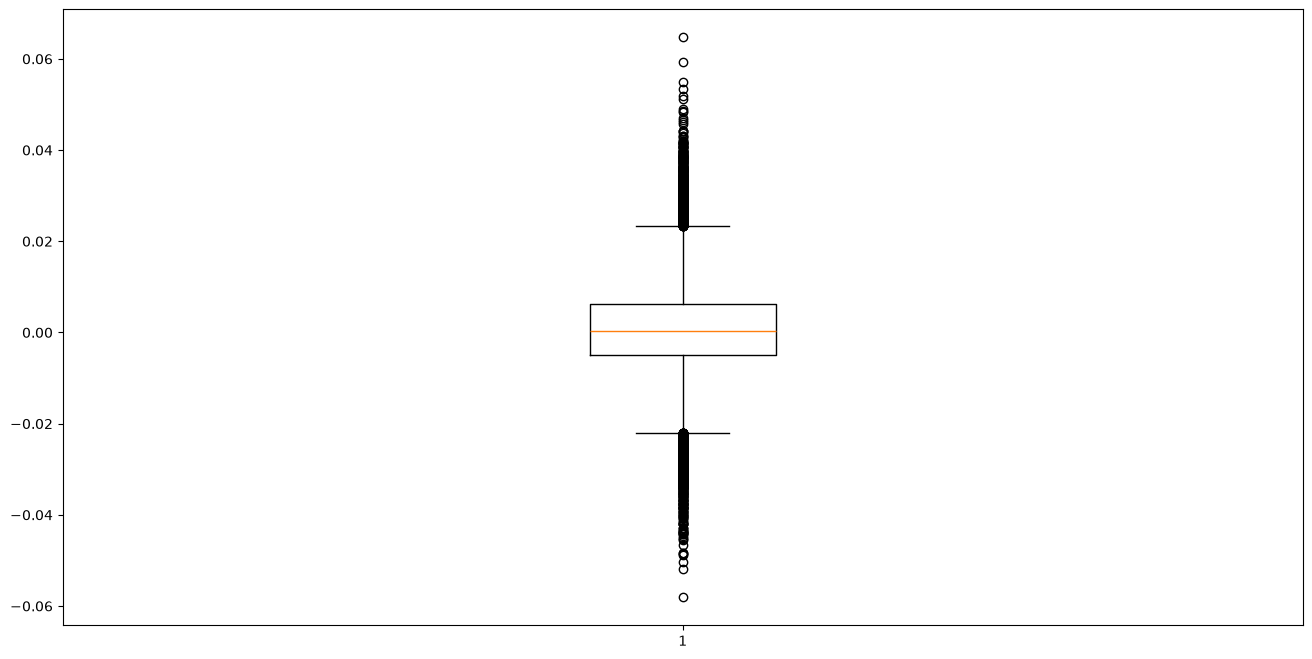

In [38]:
plt.figure(figsize= (16,8))

plt.boxplot(
    nav_his_clean_df['daily_return'].dropna()
)
plt.show()

# Bar Chart

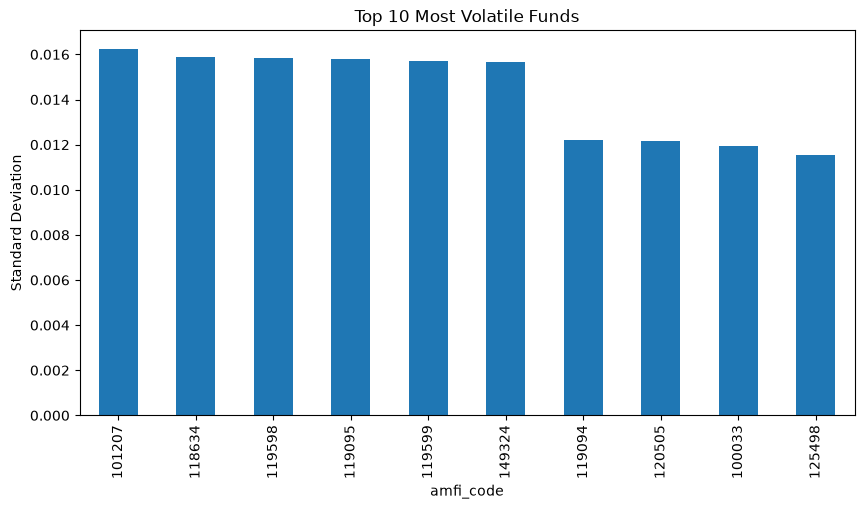

In [39]:
volatility = (
    nav_his_clean_df
    .groupby('amfi_code')['daily_return']
    .std()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
volatility.plot(kind='bar')

plt.title('Top 10 Most Volatile Funds')
plt.ylabel('Standard Deviation')

plt.show()

# Line Graph


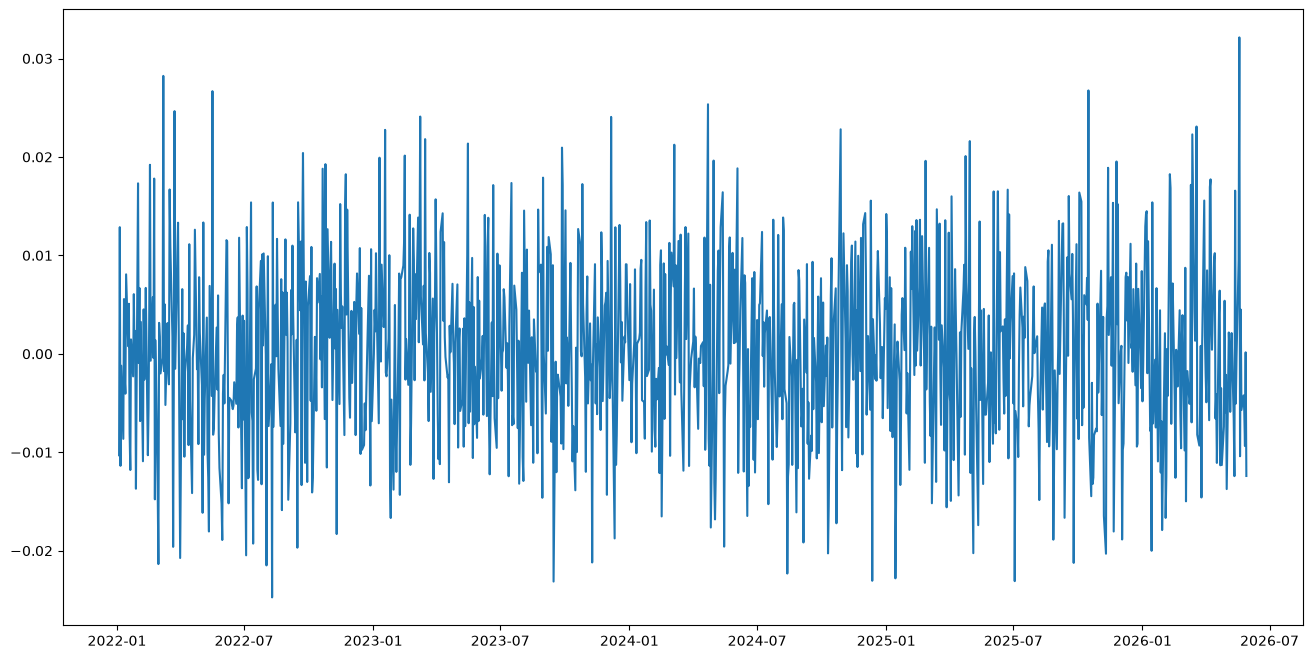

In [40]:

sample_fund = nav_his_clean_df[
    nav_his_clean_df['amfi_code'] == 100016
]
sample_fund['date'] = pd.to_datetime(sample_fund['date'])
plt.figure(figsize=(16,8))

plt.plot(
    sample_fund['date'],
    sample_fund['daily_return']
)




## Key Insights

- Daily returns are centered around zero, indicating balanced gains and losses. *(Observed from Histogram and Line Chart)*

- Most daily returns lie within a narrow range, suggesting stable fund performance. *(Observed from Boxplot and Histogram)*

- The return distribution is approximately bell-shaped, which is typical for financial data. *(Observed from Histogram)*

- Several outliers are present, indicating occasional periods of high market volatility. *(Observed from Boxplot)*

- No persistent upward or downward trend is observed in daily returns over time. *(Observed from Line Chart)*

- Overall, the daily return patterns appear realistic and consistent with mutual fund behavior. *(Observed from Summary Statistics, Histogram, Boxplot, and Line Chart)*

## CAGR (Compound Annual Growth Rate) Analysis

In [41]:
cagr_df = pd.DataFrame()

In [42]:
nav_his_clean_df = nav_his_clean_df.sort_values(
    ['amfi_code', 'date']
)

In [43]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav / start_nav) ** (1 / years) - 1

In [44]:
def calculate_n_year_cagr(group, years):

    group = group.sort_values('date')

    latest_date = group['date'].max()
    start_date = latest_date - pd.DateOffset(years=years)

    latest_nav = group.iloc[-1]['nav']

    start_data = group[group['date'] >= start_date]

    if start_data.empty:
        return None

    start_nav = start_data.iloc[0]['nav']

    return calculate_cagr(start_nav, latest_nav, years)

In [45]:
nav_his_clean_df['date'] = pd.to_datetime(
    nav_his_clean_df['date']
)

In [46]:
cagr_1y_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(lambda x: calculate_n_year_cagr(x, 1))
    .reset_index(name='1Y_CAGR')
)

cagr_3y_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(lambda x: calculate_n_year_cagr(x, 3))
    .reset_index(name='3Y_CAGR')
)

cagr_5y_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(lambda x: calculate_n_year_cagr(x, 5))
    .reset_index(name='5Y_CAGR')
)

In [47]:
cagr_df = (
    cagr_1y_df
    .merge(cagr_3y_df, on='amfi_code', how='left')
    .merge(cagr_5y_df, on='amfi_code', how='left')
)

cagr_df.head()

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


### Note

The dataset contains NAV history from January 2022 to May 2026 (~4.4 years). Therefore, true 5-Year CAGR could not be computed. The CAGR calculated using the maximum available historical period has been used as a proxy for 5-Year CAGR.

# Sharpe Ratio Analysis

In [48]:
import numpy as np
rf = 0.065
daily_rf = rf / 252

In [49]:
def calculate_sharpe_ratio(group):

    mean_return = group['daily_return'].mean()

    std_return = group['daily_return'].std()

    if std_return == 0:
        return None

    rf = 0.065
    daily_rf = rf / 252

    sharpe_ratio = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    return sharpe_ratio

In [50]:
sharpe_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(calculate_sharpe_ratio)
    .reset_index(name='Sharpe_Ratio')
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [51]:
sharpe_df['Rank'] = (
    sharpe_df['Sharpe_Ratio']
    .rank(ascending=False)
)

sharpe_df = sharpe_df.sort_values(
    'Sharpe_Ratio',
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


### Sharpe Ratio Analysis

- Sharpe Ratio was calculated for all mutual funds using daily returns.
- A risk-free rate of 6.5% was used.
- Higher Sharpe Ratios indicate superior risk-adjusted performance.
- All funds were ranked based on their Sharpe Ratios.

# Sortino Ratio Analysis

In [52]:
def calculate_sortino_ratio(group):

    mean_return = group['daily_return'].mean()

    negative_returns = group[
        group['daily_return'] < 0
    ]['daily_return']

    downside_deviation = negative_returns.std()

    if downside_deviation == 0:
        return None

    rf = 0.065
    daily_rf = rf / 252

    sortino_ratio = (
        (mean_return - daily_rf)
        / downside_deviation
    ) * np.sqrt(252)

    return sortino_ratio

In [53]:
sortino_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(calculate_sortino_ratio)
    .reset_index(name='Sortino_Ratio')
)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [54]:
sortino_df['Rank'] = (
    sortino_df['Sortino_Ratio']
    .rank(ascending=False)
)

sortino_df = sortino_df.sort_values(
    'Sortino_Ratio',
    ascending=False
)

sortino_df.head()

,amfi_code,Sortino_Ratio,Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0


#  Alpha & Beta Calculation

In [55]:
from scipy.stats import linregress

In [56]:
benchmark_df = pd.read_csv('../data/raw/10_benchmark_indice.csv')

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [57]:
benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date']
)

In [58]:
benchmark_df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [59]:
nifty100_df = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
]

In [60]:
nifty100_df = nifty100_df.sort_values('date')

nifty100_df['benchmark_return'] = (
    nifty100_df['close_value']
    .pct_change()
)

nifty100_df.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [61]:
nav_his_clean_df['date'] = pd.to_datetime(
    nav_his_clean_df['date']
)

In [62]:
merged_df = pd.merge(
    nav_his_clean_df,
    nifty100_df[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged_df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [63]:
from scipy.stats import linregress

def calculate_alpha_beta(group):

    group = group.dropna(
        subset=['daily_return', 'benchmark_return']
    )

    if len(group) < 2:
        return pd.Series({
            'Alpha': None,
            'Beta': None
        })

    regression = linregress(
        group['benchmark_return'],
        group['daily_return']
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    return pd.Series({
        'Alpha': alpha,
        'Beta': beta
    })

In [64]:
alpha_beta_df = (
    merged_df
    .groupby('amfi_code')
    .apply(calculate_alpha_beta)
    .reset_index()
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [65]:
alpha_beta_df.to_csv(
    '../reports/alpha_beta.csv',
    index=False
)

# Maximum Drawdown Analysis

In [66]:
def calculate_max_drawdown(group):

    group = group.sort_values('date').copy()

    group['running_max'] = (
        group['nav'].cummax()
    )

    group['drawdown'] = (
        group['nav']
        / group['running_max']
        - 1
    )

    worst_drawdown = group['drawdown'].min()

    end_idx = group['drawdown'].idxmin()

    drawdown_end_date = group.loc[
        end_idx,
        'date'
    ]

    peak_before = group.loc[:end_idx]

    peak_idx = peak_before['nav'].idxmax()

    drawdown_start_date = group.loc[
        peak_idx,
        'date'
    ]

    return pd.Series({
        'Max_Drawdown': worst_drawdown,
        'Drawdown_Start': drawdown_start_date,
        'Drawdown_End': drawdown_end_date
    })

In [67]:
max_drawdown_df = (
    nav_his_clean_df
    .groupby('amfi_code')
    .apply(calculate_max_drawdown)
    .reset_index()
)

max_drawdown_df.head()

,amfi_code,Max_Drawdown,Drawdown_Start,Drawdown_End
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


#  Fund Scorecard Creation

In [69]:

scheme_performance_df = pd.read_csv(
    '../data/processed/scheme_performance.csv'
)

scheme_performance_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [72]:
scorecard_df = (
    cagr_3y_df
    .merge(
        sharpe_df[['amfi_code', 'Sharpe_Ratio']],
        on='amfi_code',
        how='left'
    )
    .merge(
        alpha_beta_df[['amfi_code', 'Alpha']],
        on='amfi_code',
        how='left'
    )
   .merge(
    scheme_performance_df[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code',
    how='left'
)
    .merge(
        max_drawdown_df[['amfi_code', 'Max_Drawdown']],
        on='amfi_code',
        how='left'
    )
)

scorecard_df.head()

,amfi_code,3Y_CAGR,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown
0,100016,0.012926,-0.201517,0.037476,1.55,-0.247344
1,100025,0.039164,-0.567095,0.042818,0.56,-0.043083
2,100033,0.324425,1.093699,0.271954,1.38,-0.162172
3,101206,0.289677,1.027213,0.213998,1.60,-0.112916
4,101207,-0.041524,0.162661,0.108971,1.53,-0.354469


In [73]:
scorecard_df['Return_Rank'] = scorecard_df['3Y_CAGR'].rank(ascending=False)

scorecard_df['Sharpe_Rank'] = scorecard_df['Sharpe_Ratio'].rank(ascending=False)

scorecard_df['Alpha_Rank'] = scorecard_df['Alpha'].rank(ascending=False)


scorecard_df['Expense_Rank'] = scorecard_df['expense_ratio_pct'].rank(ascending=True)


scorecard_df['Drawdown_Rank'] = scorecard_df['Max_Drawdown'].rank(ascending=False)

In [74]:
scorecard_df['Composite_Score'] = (
      scorecard_df['Return_Rank'] * 0.30
    + scorecard_df['Sharpe_Rank'] * 0.25
    + scorecard_df['Alpha_Rank'] * 0.20
    + scorecard_df['Expense_Rank'] * 0.15
    + scorecard_df['Drawdown_Rank'] * 0.10
)

In [76]:
scorecard_df['Composite_Score'] = 100 * (
    scorecard_df['Composite_Score'].max()
    - scorecard_df['Composite_Score']
) / (
    scorecard_df['Composite_Score'].max()
    - scorecard_df['Composite_Score'].min()
)

In [79]:
scorecard_df['Final_Rank'] = (
    scorecard_df['Composite_Score']
    .rank(ascending=False)
)

scorecard_df = scorecard_df.sort_values(
    by='Final_Rank'
)
scorecard_df.head()

,amfi_code,3Y_CAGR,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Composite_Score,Final_Rank
34,148567,0.340009,1.448291,0.269838,1.46,-0.112657,2.0,1.0,7.0,23.0,8.0,100.000000,1.0
25,120505,0.317775,1.180101,0.292636,1.36,-0.181885,5.0,5.0,3.0,15.0,25.0,94.439618,2.0
30,120843,0.295828,1.306744,0.273305,1.45,-0.129740,7.0,2.0,5.0,22.0,13.0,94.092094,3.0
2,100033,0.324425,1.093699,0.271954,1.38,-0.162172,4.0,7.0,6.0,17.0,20.0,92.354474,4.0
24,120504,0.324874,1.026524,0.211948,0.80,-0.125883,3.0,10.0,13.0,12.0,12.0,91.311903,5.0


In [80]:
scorecard_df.to_csv(
    '../reports/fund_scorecard.csv',
    index=False
)

#  Benchmark Comparison

In [81]:
top5_funds = (
    scorecard_df
    .sort_values('Final_Rank')
    .head(5)
)

top5_codes = top5_funds['amfi_code'].tolist()

top5_codes

[148567, 120505, 120843, 100033, 120504]

In [82]:
latest_date = nav_his_clean_df['date'].max()

start_date = latest_date - pd.DateOffset(years=3)

last3yr_df = nav_his_clean_df[
    (nav_his_clean_df['date'] >= start_date) &
    (nav_his_clean_df['amfi_code'].isin(top5_codes))
].copy()

In [83]:
last3yr_df = last3yr_df.sort_values(
    ['amfi_code', 'date']
)

last3yr_df['Cumulative_Return'] = (
    last3yr_df
    .groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [84]:
benchmark_df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [85]:
benchmark_subset = benchmark_df[
    benchmark_df['index_name'].isin(
        ['NIFTY50', 'NIFTY100']
    )
].copy()

In [86]:
benchmark_subset = benchmark_subset[
    benchmark_subset['date'] >= start_date
]

In [87]:
benchmark_subset = benchmark_subset.sort_values(
    ['index_name', 'date']
)

In [88]:
benchmark_subset['Cumulative_Return'] = (
    benchmark_subset
    .groupby('index_name')['close_value']
    .transform(lambda x: x / x.iloc[0] * 100)
)

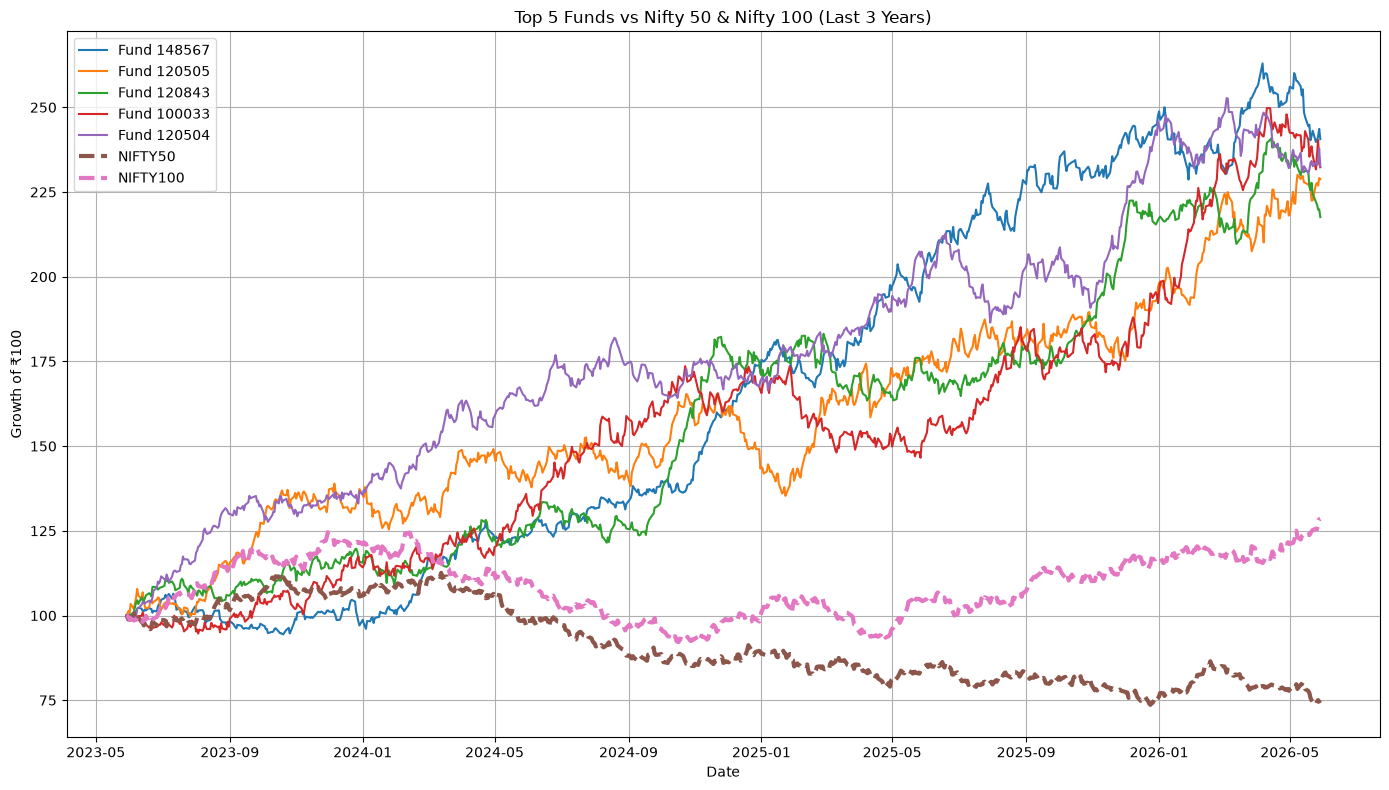

In [ ]:
plt.figure(figsize=(14,8))



for code in top5_codes:

    fund = last3yr_df[
        last3yr_df['amfi_code'] == code
    ]

    plt.plot(
        fund['date'],
        fund['Cumulative_Return'],
        label=f'Fund {code}'
    )



for index in ['NIFTY50', 'NIFTY100']:

    benchmark = benchmark_subset[
        benchmark_subset['index_name'] == index
    ]

    plt.plot(
        benchmark['date'],
        benchmark['Cumulative_Return'],
        linewidth=3,
        linestyle='--',
        label=index
    )

plt.title(
    'Top 5 Funds vs Nifty 50 & Nifty 100 (Last 3 Years)'
)

plt.xlabel('Date')
plt.ylabel('Growth of ₹100')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    '../reports/benchmark_comparison_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [90]:
tracking_df = pd.merge(
    nav_his_clean_df,
    nifty100_df[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

In [91]:
def calculate_tracking_error(group):

    group = group.dropna(
        subset=['daily_return',
                'benchmark_return']
    )

    active_return = (
        group['daily_return']
        - group['benchmark_return']
    )

    tracking_error = (
        active_return.std()
        * np.sqrt(252)
    )

    return tracking_error

In [92]:
tracking_error_df = (
    tracking_df
    .groupby('amfi_code')
    .apply(calculate_tracking_error)
    .reset_index(name='Tracking_Error')
)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


### Benchmark Comparison Analysis

- Top 5 funds based on composite score were selected.
- Benchmark comparison was performed against Nifty 50 and Nifty 100.
- Performance was compared over the last 3 years using cumulative returns.
- Tracking Error was calculated to measure deviation from benchmark performance.